# Load Dataset

In [1]:
!pip install transformers[torch]
!pip install datasets
!pip install accelerate
!pip install evaluate
!pip install bert-score
!pip install sacrebleu
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 22.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00
    

In [2]:
import torch
import transformers
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from nltk.util import ngrams
from wordcloud import WordCloud
from torch.utils.data import Dataset, DataLoader
from transformers import T5Tokenizer, T5ForConditionalGeneration
from transformers import AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import load_dataset
from sacrebleu.metrics import BLEU, CHRF, TER
from bert_score import score as bert_score
from nltk.translate.meteor_score import meteor_score

from datasets import Dataset as DatasetHF
from transformers import AdamW, get_linear_schedule_with_warmup
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm

In [3]:
nusax_mt = load_dataset("indonlp/NusaX-MT")
nusax_jav_ind = load_dataset("indonlp/NusaX-MT", name='ind-jav')

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.64k [00:00<?, ?B/s]

NusaX-MT.py:   0%|          | 0.00/5.69k [00:00<?, ?B/s]

The repository for indonlp/NusaX-MT contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/indonlp/NusaX-MT.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

## Train

In [4]:
df_train = nusax_jav_ind['train'].to_pandas()
df_train.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,Nikmati cicilan 0% hingga 12 bulan untuk pemes...,Nikmatono cicilan 0% sampek 12 sasi dinggo pes...,ind,jav
1,1,Kue-kue yang disajikan bikin saya bernostalgia...,Roti-roti sing disajekne nggarai aku nostalgia...,ind,jav
2,2,Ibu pernah bekerja di grab indonesia,Ibu uwis tahu kerja ing grab indonesia,ind,jav
3,3,Paling suka banget makan siang di sini ayam sa...,Paling seneng banget mangan awan ing kene pith...,ind,jav
4,4,Pelayanan bus DAMRI sangat baik,Pelayanane bis DAMRI apik banget.,ind,jav


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           500 non-null    object
 1   text_1       500 non-null    object
 2   text_2       500 non-null    object
 3   text_1_lang  500 non-null    object
 4   text_2_lang  500 non-null    object
dtypes: object(5)
memory usage: 19.7+ KB


## Test

In [6]:
df_test = nusax_jav_ind['test'].to_pandas()
df_test.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,"Dekat dengan hotel saya menginap, hanya ditemp...","Cepak saka hotelku nginep, namung digawa mlaku...",ind,jav
1,1,"Iya benar, dia sedang jaga warung.","Iya bener, deknen lagi jaga warung.",ind,jav
2,2,Kangkungnya lumayan tapi kepiting saus padangn...,Kangkunge lumayan nanging yuyu saus padange ng...,ind,jav
3,3,Bertempat di braga city walk yang satu gedung ...,Manggon nang braga city walk sing sak gedung k...,ind,jav
4,4,Gianyar terima bantuan sosial 2018 sebesar rp ...,Gianyar nompo bantuan sosial 2018 gedene rp 44...,ind,jav


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           400 non-null    object
 1   text_1       400 non-null    object
 2   text_2       400 non-null    object
 3   text_1_lang  400 non-null    object
 4   text_2_lang  400 non-null    object
dtypes: object(5)
memory usage: 15.8+ KB


## Validation

In [8]:
df_valid = nusax_jav_ind['validation'].to_pandas()
df_valid.head()

,id,text_1,text_2,text_1_lang,text_2_lang
0,0,Jika ada pertanyaan lebih lanjut yang ingin ka...,Lak ana pitakonan sakteruse sing sir mok eruhi...,ind,jav
1,1,Rasanya sih kok harga kaki lima dan rasanya ya...,"Rasane kok rega kaki lima, lan rasane yo ora b...",ind,jav
2,2,"Minimal cek pesan saya, ada problem yang rumit...","Minimal cek pesenku, ana masalah sing ruwet, n...",ind,jav
3,3,Dulu restoran ini merupakan favorit saya karen...,Mbien restoran iki yaiku favoritku amarga rega...,ind,jav
4,4,Merupakan resto vintage dengan harga yang cuku...,Iku uga resto vintage sek regane cukup terjang...,ind,jav


In [9]:
df_valid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           100 non-null    object
 1   text_1       100 non-null    object
 2   text_2       100 non-null    object
 3   text_1_lang  100 non-null    object
 4   text_2_lang  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB


# Prepocessing

In [10]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
stopwords_df = pd.read_csv('stopword.csv')
stopwords_dict = {
    'ind': set(stopwords_df['indonesian'].dropna().tolist()),
    'jav': set(stopwords_df['javanese'].dropna().tolist()),
    'sun': set(stopwords_df['sundanese'].dropna().tolist())
}

def clean_content(content, lang):
    # Mengkonversi teks menjadi huruf kecil
    content = content.lower()

    # Menghapus tanda baca dan angka
    content = re.sub(r'[^a-z\s]', '', content)

    # Mengganti karakter yang berulang-ulang (contoh: sooo -> so)
    content = re.sub(r'(.)\1{2,}', r'\1\1', content)

    # Tokenisasi
    words = content.split()

    # Remove stopword sesuai bahasa
    words = [word for word in words if word not in stopwords_dict.get(lang, set())]

    # Menggabungkan kata-kata menjadi satu string
    cleaned_content = ' '.join(words)

    return cleaned_content


In [12]:
df_list = [df_train, df_test, df_valid]

for i, df in enumerate(df_list):
    df[f'text_1_cleaned'] = df.apply(lambda row: clean_content(row['text_1'], row['text_1_lang']), axis=1)
    df[f'text_2_cleaned'] = df.apply(lambda row: clean_content(row['text_2'], row['text_2_lang']), axis=1)

In [13]:
df_train[['text_1_cleaned','text_2_cleaned']]

,text_1_cleaned,text_2_cleaned
0,nikmati cicilan pemesanan tiket pesawat air as...,nikmatono cicilan sampek sasi dinggo pesen tik...
1,kuekue disajikan bikin bernostalgia tipikal ku...,rotiroti sing disajekne nggarai nostalgianan m...
2,grab indonesia,uwis tahu kerja grab indonesia
3,suka banget makan siang ayam sambalnya enak ba...,seneng mangan awan kene pithik sambele enak re...
4,pelayanan bus damri,pelayanane bis damri
...,...,...
495,si a omongnya tong kosong nyaring bunyinya bic...,si omonge tong kosong banter unine enek bobote
496,sambalnya terasinya khas asin manisnya pas rua...,sambele liya terasine khas tenan asin legine p...
497,steaknya enak pesan gede aja empuk sebarkan fo...,miturutku stike enak luwah pesen sing gede wae...
498,dijaga ya makannya gus emang musimnya iyasi je...,dijaga ya mangane gus pancen lagi musime iya s...


# EDA

In [14]:
df = pd.concat([df_train, df_test, df_valid], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1000 non-null   object
 1   text_1          1000 non-null   object
 2   text_2          1000 non-null   object
 3   text_1_lang     1000 non-null   object
 4   text_2_lang     1000 non-null   object
 5   text_1_cleaned  1000 non-null   object
 6   text_2_cleaned  1000 non-null   object
dtypes: object(7)
memory usage: 54.8+ KB


## Wordclound

In [15]:
def plot_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color ='white').generate(" ".join(text))
    plt.figure(figsize = (10, 8), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title)
    plt.show()

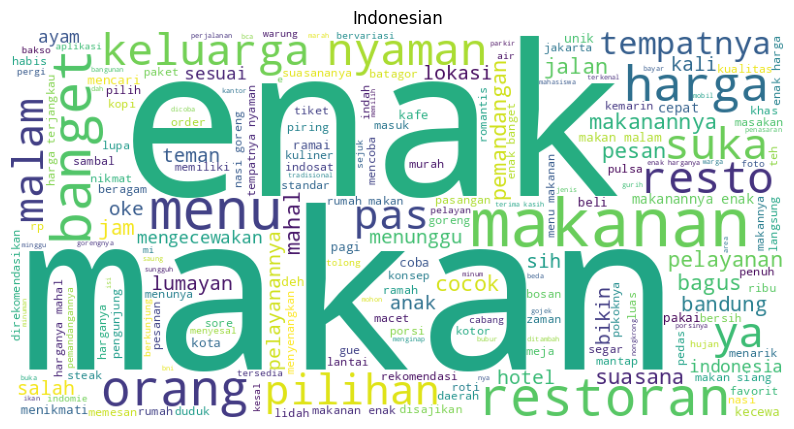

In [16]:
plot_word_cloud(df['text_1_cleaned'], 'Indonesian')

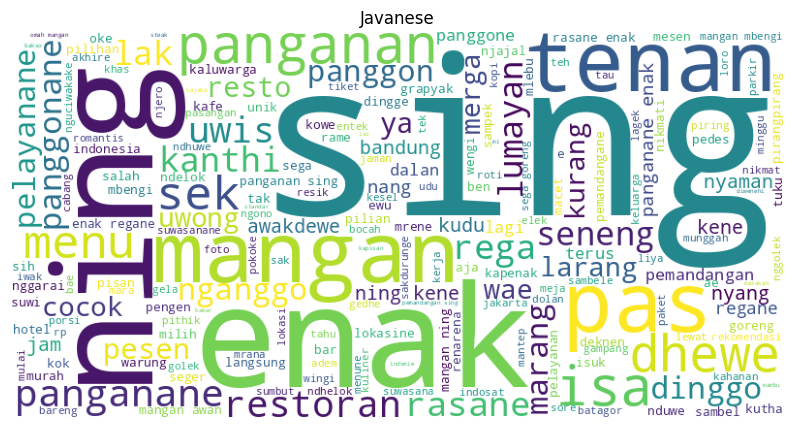

In [17]:
plot_word_cloud(df['text_2_cleaned'], 'Javanese')

## Top 10 Words

In [18]:
def bar_plot(text, title):
    word_counts = Counter(" ".join(text).split())
    top_words = word_counts.most_common(10)
    words, counts = zip(*top_words)
    plt.figure(figsize=(10, 6))
    plt.bar(words, counts)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

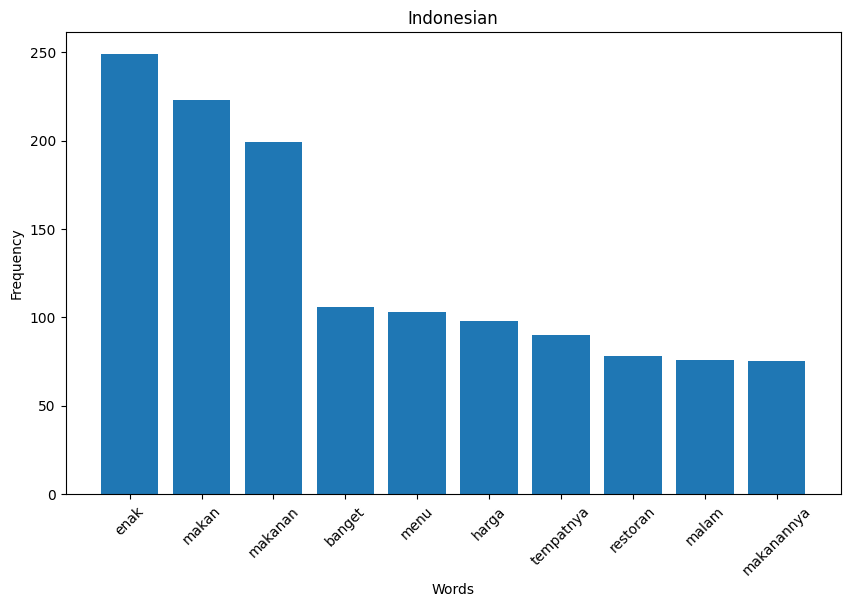

In [19]:
bar_plot(df['text_1_cleaned'], 'Indonesian')

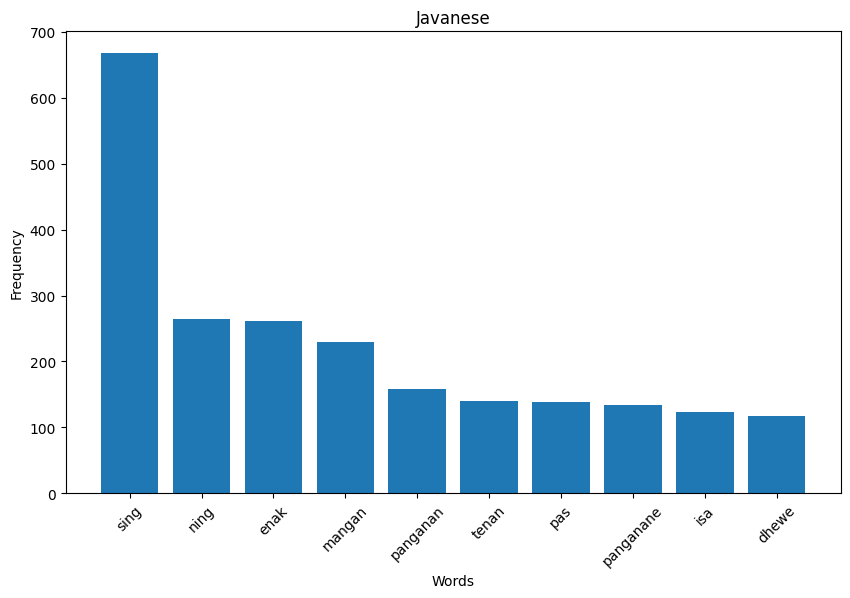

In [20]:
bar_plot(df['text_2_cleaned'], 'Javanese')

# Splitting

In [21]:
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)

val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Train data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Test data size: {len(test_data)}")

Train data size: 800
Validation data size: 100
Test data size: 100


In [22]:
# Validasi dataset untuk menghapus entri dengan nilai kosong
train_data = train_data.dropna(subset=["text_1_cleaned", "text_2_cleaned"]).reset_index(drop=True)
val_data = val_data.dropna(subset=["text_1_cleaned", "text_2_cleaned"]).reset_index(drop=True)
test_data = test_data.dropna(subset=["text_1_cleaned", "text_2_cleaned"]).reset_index(drop=True)


In [23]:
train_data.head()

,id,text_1,text_2,text_1_lang,text_2_lang,text_1_cleaned,text_2_cleaned
0,29,Saya sekeluarga sedang cari tempat makan habis...,Aku sakaluwarga lagi nggolek panggonan mangan ...,ind,jav,sekeluarga cari makan habis nonton bosan makan...,sakaluwarga lagi nggolek mangan lebar nonton d...
1,35,"Sarung bantal, seprai dan selimutnya tidak lag...","Sarung bantal, seprei lan slimute uwis ora put...",ind,jav,sarung bantal seprai selimutnya putihtrus dind...,sarung bantal seprei slimute uwis putihterus t...
2,195,"Tempat makannya sangat sederhana, namun rasany...","Panggon mangane sederhana banget, nanging rasa...",ind,jav,makannya sederhana juara komposisi bumbu kacan...,panggon mangane sederhana rasane juara komposi...
3,57,Untuk daerah banda aceh dan sekitarnya masih l...,Dinggo daerah banda aceh lan sekitare sik lanc...,ind,jav,daerah banda aceh lancar gangguan,dinggo daerah banda aceh sekitare sik lancar g...
4,336,"Saya paling tidak suka itu, kalau mendekati pe...","Aku paling ora seneng kuwi, yen nyepaki pemilu...",ind,jav,suka mendekati pemilu suasananya memanas,seneng nyepaki pemilu suasane panas


# Modelling

In [24]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load tokenizer dan model
model_name = "facebook/nllb-200-distilled-600M"  # Anda bisa mengganti ini ke model NLLB lain yang lebih besar
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

In [25]:
from datasets import Dataset

def preprocess_function(examples):
    # Pastikan input dan target tidak kosong
    inputs = examples["text_1_cleaned"]
    targets = examples["text_2_cleaned"]

    # Pastikan tidak ada nilai kosong
    inputs = [text if text is not None else "" for text in inputs]
    targets = [text if text is not None else "" for text in targets]

    # Tokenisasi input dan target menggunakan `text_target`
    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding="max_length"
    )
    model_inputs["labels"] = tokenizer(
        targets,
        max_length=128,
        truncation=True,
        padding="max_length"
    )["input_ids"]

    return model_inputs


# Konversi data menjadi dataset Hugging Face
train_dataset = Dataset.from_pandas(train_data).map(preprocess_function, batched=True)
val_dataset = Dataset.from_pandas(val_data).map(preprocess_function, batched=True)
test_dataset = Dataset.from_pandas(test_data).map(preprocess_function, batched=True)


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [26]:
train_dataset

Dataset({
    features: ['id', 'text_1', 'text_2', 'text_1_lang', 'text_2_lang', 'text_1_cleaned', 'text_2_cleaned', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 800
})

In [27]:
from transformers import DataCollatorForSeq2Seq, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer
import evaluate
import numpy as np
from transformers import T5Tokenizer

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [28]:
sacrebleu_metric = evaluate.load("sacrebleu")
meteor_metric = evaluate.load("meteor")
bertscore_metric = evaluate.load("bertscore")

# Fungsi untuk post-processing teks prediksi dan label
def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

# Fungsi untuk menghitung metrik evaluasi
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]

    # Decode predictions and labels
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Post-process teks
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    # Initialize result dictionary
    result = {}

    # Compute Accuracy
    total = len(decoded_labels)
    correct = sum(pred == label[0] for pred, label in zip(decoded_preds, decoded_labels))
    accuracy = correct / total
    result["accuracy"] = accuracy

    # Compute sacreBLEU
    bleu_result = sacrebleu_metric.compute(predictions=decoded_preds, references=decoded_labels)
    result["bleu"] = bleu_result["score"]

    # Compute METEOR
    meteor_result = meteor_metric.compute(predictions=decoded_preds, references=decoded_labels)
    result["meteor"] = meteor_result["meteor"]

    # Compute BERTScore
    bertscore_result = bertscore_metric.compute(
        predictions=decoded_preds, references=decoded_labels, lang="id"  # Indonesia ke Jawa
    )
    result["bertscore_precision"] = np.mean(bertscore_result["precision"])
    result["bertscore_recall"] = np.mean(bertscore_result["recall"])
    result["bertscore_f1"] = np.mean(bertscore_result["f1"])

    # Compute average generated length
    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in preds]
    result["gen_len"] = np.mean(prediction_lens)

    # Round metrics for readability
    result = {k: round(v, 4) for k, v in result.items()}
    return result

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [29]:
! pip install wandb

In [ ]:
import wandb

wandb.login(key="b45c3...")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [31]:
# TRAINING
training_args = Seq2SeqTrainingArguments(
    output_dir="NLLB_Ind_Jav_checkpoints",  # Output directory
    evaluation_strategy="epoch",           # Evaluasi setiap epoch
    learning_rate=3e-5,                    # Learning rate
    per_device_train_batch_size=8,         # Batch size
    per_device_eval_batch_size=8,          # Batch size evaluasi
    weight_decay=0.01,                     # L2 regularization
    save_total_limit=3,                    # Maksimal checkpoint
    num_train_epochs=10,                    # Jumlah epoch
    predict_with_generate=True,            # Generate teks untuk evaluasi
    fp16=True,                             # Mixed precision
    gradient_accumulation_steps=4          # Gradient accumulation
)

# Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics  # Fungsi evaluasi yang sama
)

trainer.train()

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-31-ee587a08115a>:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: andreashendraherwanto (andreashendraherwanto-independent). Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Bleu,Meteor,Bertscore Precision,Bertscore Recall,Bertscore F1,Gen Len
1,No log,9.597585,0.000000,9.264000,0.313400,0.793300,0.765100,0.778800,24.300000
2,No log,7.936422,0.000000,9.054100,0.344200,0.803200,0.778400,0.790400,25.110000
3,No log,6.849563,0.000000,8.885800,0.352200,0.802500,0.778800,0.790200,26.970000
4,No log,6.277804,0.000000,9.034400,0.359600,0.804300,0.780700,0.792100,27.170000
5,No log,5.887561,0.000000,9.721300,0.367100,0.807900,0.784500,0.795800,27.310000
6,No log,5.620918,0.000000,10.130100,0.373900,0.811100,0.787200,0.798700,27.390000
7,No log,5.430052,0.000000,10.122300,0.374900,0.811200,0.787400,0.798900,27.420000
8,No log,5.299274,0.000000,10.166100,0.375300,0.812300,0.788200,0.799800,27.460000
9,No log,5.220155,0.000000,10.334400,0.378700,0.813600,0.789400,0.801000,27.460000
10,No log,5.188026,0.000000,10.209000,0.374400,0.809700,0.786700,0.797700,29.270000


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

TrainOutput(global_step=250, training_loss=6.98298681640625, metrics={'train_runtime': 548.435, 'train_samples_per_second': 14.587, 'train_steps_per_second': 0.456, 'total_flos': 2167104602112000.0, 'train_loss': 6.98298681640625, 'epoch': 10.0})

# Prediction

In [32]:
# Evaluate on test dataset
results = trainer.evaluate(test_dataset)
print("Evaluation Results:", results)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

Evaluation Results: {'eval_loss': 5.234711647033691, 'eval_accuracy': 0.01, 'eval_bleu': 14.7907, 'eval_meteor': 0.3907, 'eval_bertscore_precision': 0.8201, 'eval_bertscore_recall': 0.7967, 'eval_bertscore_f1': 0.8079, 'eval_gen_len': 23.69, 'eval_runtime': 19.633, 'eval_samples_per_second': 5.093, 'eval_steps_per_second': 0.662, 'epoch': 10.0}


In [40]:
# Melakukan prediksi pada data uji dengan NLLB
predictions = trainer.predict(test_dataset)

# Hasil prediksi berupa tensor, kita perlu mengonversinya ke teks
predicted_ids = predictions.predictions  # Tensor prediksi
decoded_predictions = tokenizer.batch_decode(predicted_ids, skip_special_tokens=True)

# Menyusun hasil dalam DataFrame untuk melihat hasil terjemahan
df_nllb_predictions = pd.DataFrame({
    'input_text': tokenizer.batch_decode(test_dataset['input_ids'], skip_special_tokens=True),
    'predicted_translation': decoded_predictions
})

df_nllb_predictions
df_nllb_predictions.to_csv('nllb_predictions.csv', index=False)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.


Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
Trainer.tokenizer is now deprecated. You should use Tr

In [42]:
df_nllb_predictions

,input_text,predicted_translation
0,bosan kali kenal ayam goreng suharti langsung ...,bosen kali kenal ayam goreng suharti langsung ...
1,menunggu makanannya banget waitressnya galak p...,nunggu manganane tenan pelayanane galak pas pa...
2,warga jakarta malu kang oknum bertanggung swee...,warga jakarta malu kang oknum tanggung jawab n...
3,bakso favorit sekeluarga gurih super enak dite...,bakso favorit sekeluarga gurih super enak dite...
4,bubur ahong enak dimakan makan malam menu dini...,bubur ahong enak dipangan mangan bengi menu di...
...,...,...
95,mengunjungi rumah makan diajak rekan bisnis me...,ngunjungi omah mangan diajak kanca bisnis sene...
96,anw indomie ku semalam nikmat,awak indomie ku bengi sing enak
97,kalap belanja memutuskan makan warung tenda pi...,kalap belanja mutusake mangan warung tenda pin...
98,pasangan petahana pilkada garut unggul,pasangan petahana pilkada garut unggul


## Translation

In [44]:
import torch

source_text = "Saya makan ayam goreng di rumah tadi malam."

inputs = tokenizer(
    source_text,
    return_tensors="pt",
    max_length=128,
    truncation=True,
    padding="max_length"
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
inputs = {
    "input_ids": inputs["input_ids"].to(device),
    "attention_mask": inputs["attention_mask"].to(device),
}

output = model.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    forced_bos_token_id=tokenizer.convert_tokens_to_ids("jav_Latn"),
    max_length=128,
    num_beams=4
)

translated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print("Source:", source_text)
print("Translation:", translated_text)

Source: Saya makan ayam goreng di rumah tadi malam.
Translation: Aku mangan pitik goreng ing omah mbengi.


## Save model

In [36]:
# import pickle
# from google.colab import files

# # Simpan model ke .pkl
# with open("nllb_model.pkl", "wb") as f:
#     pickle.dump(model, f)

# # Unduh file .pkl
# files.download("nllb_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>